In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")


✅ Libraries imported!


In [4]:
# Use your FULL path
df = pd.read_csv(r'C:\Users\power\Desktop\advanced-phishing-detection-system\ml\data\raw\phishing_email.csv')

print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

✅ Dataset loaded successfully!
Dataset shape: (82486, 2)


In [3]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))

Current working directory: c:\Users\power\Desktop\advanced-phishing-detection-system\ml\notebooks
Files in current directory: ['01-data-exploration.ipynb']


In [5]:
# Cell 1: Basic info
print("Dataset shape:", df.shape)
print("Number of rows (emails):", df.shape[0])
print("Number of columns (features):", df.shape[1])

Dataset shape: (82486, 2)
Number of rows (emails): 82486
Number of columns (features): 2


In [6]:
# Cell 2: Column names
print("Column names:")
print(df.columns.tolist())

Column names:
['text_combined', 'label']


In [7]:
# Cell 3: First 5 rows
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [8]:
# Cell 4: Last 5 rows
df.tail()

,text_combined,label
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [13]:
# Cell 6: Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
text_combined    0
label            0
dtype: int64


In [12]:
# Cell 7: Basic statistics for numerical columns
df.describe()

,label
count,82486.000000
mean,0.519979
std,0.499604
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [11]:
# Look for columns that might be the label (0/1 values)
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and df[col].nunique() <= 10:
        print(f"\n📌 Column: {col}")
        print(f"Unique values: {df[col].unique()}")
        print(f"Value counts:\n{df[col].value_counts()}")


📌 Column: label
Unique values: [0 1]
Value counts:
label
1    42891
0    39595
Name: count, dtype: int64


In [17]:
# Replace 'label' with your actual column name
label_col = 'label'  # CHANGE THIS
print(f"Label column: {label_col}")

Label column: label


In [18]:
# Look for columns containing text
for col in df.columns:
    if df[col].dtype == 'object':  # object columns often contain text
        print(f"\n📧 Column: {col}")
        print(f"Sample value (first 200 chars):")
        print(str(df[col].iloc[0])[:200])
        print("-" * 50)

In [19]:
# Replace 'text' with your actual column name
text_col = 'text'  # CHANGE THIS
print(f"Text column: {text_col}")

Text column: text


label
1    42891
0    39595
Name: count, dtype: int64

Percentages:
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


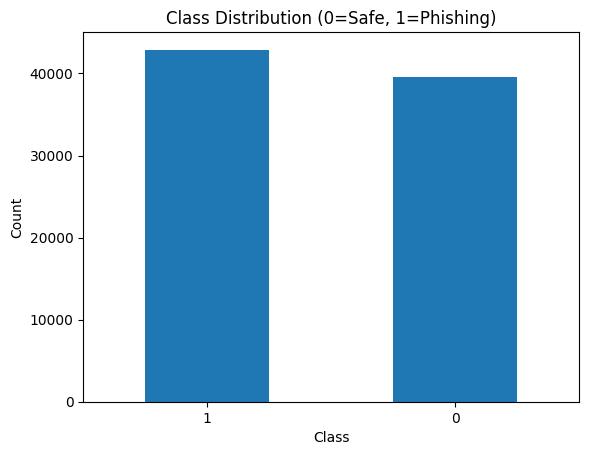

In [20]:
# Check distribution
print(df[label_col].value_counts())

# Calculate percentages
percentages = df[label_col].value_counts(normalize=True) * 100
print(f"\nPercentages:\n{percentages}")

# Visualize
import matplotlib.pyplot as plt
df[label_col].value_counts().plot(kind='bar')
plt.title('Class Distribution (0=Safe, 1=Phishing)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [23]:
# See all column names
print("Column names in your dataset:")
print(df.columns.tolist())

Column names in your dataset:
['text_combined', 'label']


In [24]:
# Set the correct column names
text_col = 'text_combined'  # This is your text column
label_col = 'label'         # This is your label column

print(f"✅ Text column: {text_col}")
print(f"✅ Label column: {label_col}")

✅ Text column: text_combined
✅ Label column: label


In [25]:
# Add email length features
df['email_length'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
df['sentence_count'] = df[text_col].astype(str).apply(lambda x: x.count('. ') + x.count('! ') + x.count('? '))

print("✅ Added length features")

✅ Added length features


In [26]:
# Check distribution
print(df[label_col].value_counts())

# Calculate percentages
percentages = df[label_col].value_counts(normalize=True) * 100
print(f"\nPercentages:\n{percentages}")

label
1    42891
0    39595
Name: count, dtype: int64

Percentages:
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


In [27]:
# Count urgent words
urgent_words = ['urgent', 'immediately', 'suspended', 'verify', 'account']
df['urgent_word_count'] = df[text_col].apply(
    lambda x: sum(1 for word in urgent_words if word in str(x).lower())
)

In [28]:
# Compare basic statistics between classes
df.groupby(label_col)[['email_length', 'word_count', 'sentence_count']].describe()

email_length                                                         \
             count         mean           std   min    25%    50%     75%   
label                                                                       
0          39595.0  1536.096098   3695.897909  11.0  411.0  779.0  1493.0   
1          42891.0  1060.413793  21192.696303   1.0  241.0  391.0  1058.0   

                 word_count              ...                  sentence_count  \
             max      count        mean  ...    75%       max          count   
label                                    ...                                   
0       160318.0    39595.0  203.182068  ...  203.0   23359.0        39595.0   
1      4279526.0    42891.0  121.342543  ...  154.0  107710.0        42891.0   

                                          
      mean  std  min  25%  50%  75%  max  
label                                     
0      0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1      0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[2 rows x 24 columns]

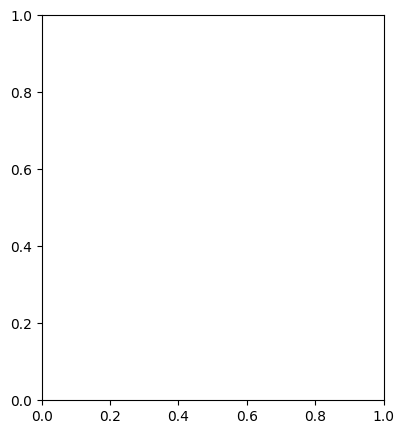

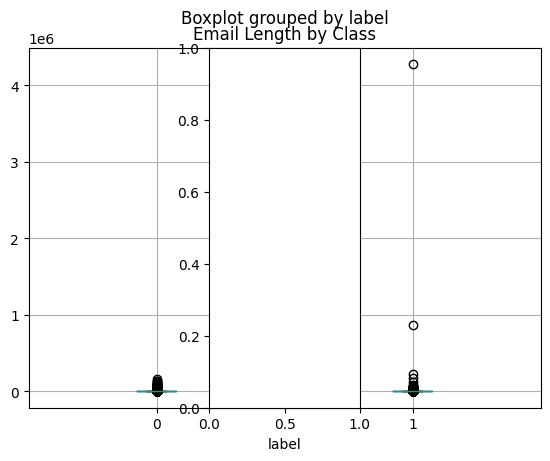

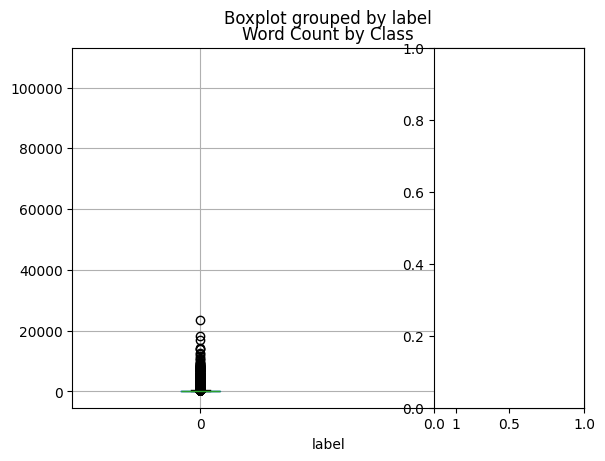

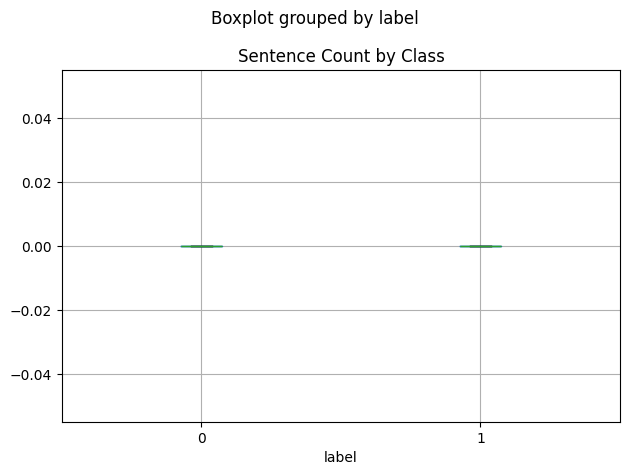

In [29]:
# Visualize the differences
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df.boxplot(column='email_length', by=label_col)
plt.title('Email Length by Class')

plt.subplot(1, 3, 2)
df.boxplot(column='word_count', by=label_col)
plt.title('Word Count by Class')

plt.subplot(1, 3, 3)
df.boxplot(column='sentence_count', by=label_col)
plt.title('Sentence Count by Class')

plt.tight_layout()
plt.show()

In [30]:
# Create a list of words often found in phishing emails
urgent_words = ['urgent', 'immediately', 'suspended', 'verify', 'account', 
                'click', 'limited', 'bank', 'paypal', 'password', 
                'update', 'confirm', 'security', 'unusual', 'alert',
                'restricted', 'locked', 'access', 'login', 'credential']

# Function to count urgent words
def count_urgent_words(text):
    text = str(text).lower()
    return sum(1 for word in urgent_words if word in text)

# Apply to your dataset
df['urgent_word_count'] = df[text_col].apply(count_urgent_words)

# Compare between classes
print(df.groupby(label_col)['urgent_word_count'].describe())

         count      mean       std  min  25%  50%  75%   max
label                                                       
0      39595.0  0.599444  1.059730  0.0  0.0  0.0  1.0  13.0
1      42891.0  0.849059  1.369051  0.0  0.0  0.0  1.0  19.0


<Figure size 1000x600 with 0 Axes>

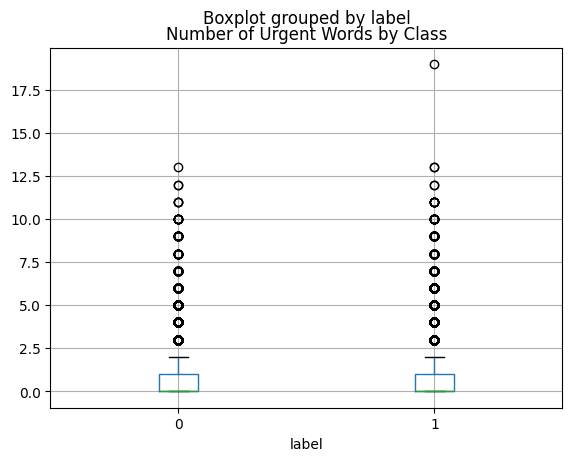

In [31]:
# Visualize
plt.figure(figsize=(10, 6))
df.boxplot(column='urgent_word_count', by=label_col)
plt.title('Number of Urgent Words by Class')
plt.show()

In [32]:
# Count how many links appear in each email
import re

def count_links(text):
    text = str(text)
    # Look for http, https, www patterns
    links = re.findall(r'http[s]?://|www\.', text)
    return len(links)

df['link_count'] = df[text_col].apply(count_links)

# Compare between classes
print(df.groupby(label_col)['link_count'].describe())

         count  mean  std  min  25%  50%  75%  max
label                                             
0      39595.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
1      42891.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [33]:
# Look at 3 sample emails
for i in range(3):
    print(f"\n--- Email {i+1} ---")
    print(df[text_col].iloc[i][:500])  # First 500 chars
    print("-" * 50)


--- Email 1 ---
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls
--------------------------------------------------

--- Email 2 ---
nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nomination 33 750 forwarded eileen ponton houston pefs pec 05 29 01 08 36 charlie stone eileen ponton melissa jones com hpl scheduling enron com liz bellamy enron com szajac enron com 05 25 01 subject nom actu
--------------------------------------------------

--- Email 3 ---
enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 000 receive actuals duke forward
--------------------------------------------------


In [34]:
import re

def find_any_link(text):
    text = str(text)
    
    # Try different link patterns
    patterns = {
        'http': r'http[s]?://',
        'www': r'www\.',
        'click here': r'click here',
        'url': r'url=',
        'href': r'href=',
        'link': r'link',
        'dot com': r'\.com',
        'dot org': r'\.org',
        'dot net': r'\.net'
    }
    
    results = {}
    for name, pattern in patterns.items():
        matches = re.findall(pattern, text.lower())
        results[name] = len(matches)
    
    return results

# Test on first few emails
for i in range(5):
    print(f"\nEmail {i+1}:")
    print(find_any_link(df[text_col].iloc[i]))


Email 1:
{'http': 0, 'www': 0, 'click here': 0, 'url': 0, 'href': 0, 'link': 0, 'dot com': 0, 'dot org': 0, 'dot net': 0}

Email 2:
{'http': 0, 'www': 0, 'click here': 0, 'url': 0, 'href': 0, 'link': 0, 'dot com': 0, 'dot org': 0, 'dot net': 0}

Email 3:
{'http': 0, 'www': 0, 'click here': 0, 'url': 0, 'href': 0, 'link': 0, 'dot com': 0, 'dot org': 0, 'dot net': 0}

Email 4:
{'http': 0, 'www': 0, 'click here': 0, 'url': 0, 'href': 0, 'link': 0, 'dot com': 0, 'dot org': 0, 'dot net': 0}

Email 5:
{'http': 0, 'www': 0, 'click here': 0, 'url': 0, 'href': 0, 'link': 0, 'dot com': 0, 'dot org': 0, 'dot net': 0}


In [35]:
from bs4 import BeautifulSoup

def extract_links_from_html(text):
    text = str(text)
    try:
        # Try to parse as HTML
        soup = BeautifulSoup(text, 'html.parser')
        # Find all anchor tags
        links = soup.find_all('a')
        # Find all href attributes
        hrefs = [link.get('href', '') for link in links]
        # Also find any http/https in the text
        http_links = re.findall(r'http[s]?://[^\s<>"\'()]+', text)
        return len(hrefs) + len(http_links)
    except:
        # If HTML parsing fails, just count http patterns
        return len(re.findall(r'http[s]?://', text))

# Install BeautifulSoup first (run once in a cell)
# !pip install beautifulsoup4

# Then apply
df['html_link_count'] = df[text_col].apply(extract_links_from_html)
print(df['html_link_count'].value_counts())

html_link_count
0    82486
Name: count, dtype: int64


In [36]:
from bs4 import BeautifulSoup

def extract_links_from_html(text):
    text = str(text)
    try:
        # Try to parse as HTML
        soup = BeautifulSoup(text, 'html.parser')
        # Find all anchor tags
        links = soup.find_all('a')
        # Find all href attributes
        hrefs = [link.get('href', '') for link in links]
        # Also find any http/https in the text
        http_links = re.findall(r'http[s]?://[^\s<>"\'()]+', text)
        return len(hrefs) + len(http_links)
    except:
        # If HTML parsing fails, just count http patterns
        return len(re.findall(r'http[s]?://', text))

# Install BeautifulSoup first (run once in a cell)
# !pip install beautifulsoup4

# Then apply
df['html_link_count'] = df[text_col].apply(extract_links_from_html)
print(df['html_link_count'].value_counts())

html_link_count
0    82486
Name: count, dtype: int64


In [37]:
def find_all_urls(text):
    text = str(text)
    # Pattern for URLs
    url_pattern = r'https?://[^\s<>"\'()]+|www\.[^\s<>"\'()]+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}(?:/[^\s<>"\'()]*)?'
    
    urls = re.findall(url_pattern, text.lower())
    
    # Filter out common false positives
    filtered_urls = [url for url in urls if len(url) > 4 and '.' in url]
    
    return len(filtered_urls)

df['url_count'] = df[text_col].apply(find_all_urls)
print(df.groupby(label_col)['url_count'].describe())

         count  mean  std  min  25%  50%  75%  max
label                                             
0      39595.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
1      42891.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [38]:
# Check how many of each class
print(df[label_col].value_counts())

# Look at some examples labeled as phishing (1)
print("\n📧 Examples labeled as phishing (label=1):")
phishing_examples = df[df[label_col] == 1][text_col].head(5)
for i, email in enumerate(phishing_examples):
    print(f"\n--- Phishing Email {i+1} ---")
    print(email[:300])
    print("-" * 50)

label
1    42891
0    39595
Name: count, dtype: int64

📧 Examples labeled as phishing (label=1):

--- Phishing Email 1 ---
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www c
--------------------------------------------------

--- Phishing Email 2 ---
indemand payperview movies sports wed 15 sep 2004 11 33 14 0500 hi cable tv subscriber per per view filters lets get pay per view mature channels movie channels sporting events nothing country game feel fig contain tone current wheels race end young coast bear fact energy belong discovered yet ball 
--------------------------------------------------

--- Phishing Email 3 ---
want lose 19 weight try adipren hello special offer want lose weight powerful weightloss available without prescription n

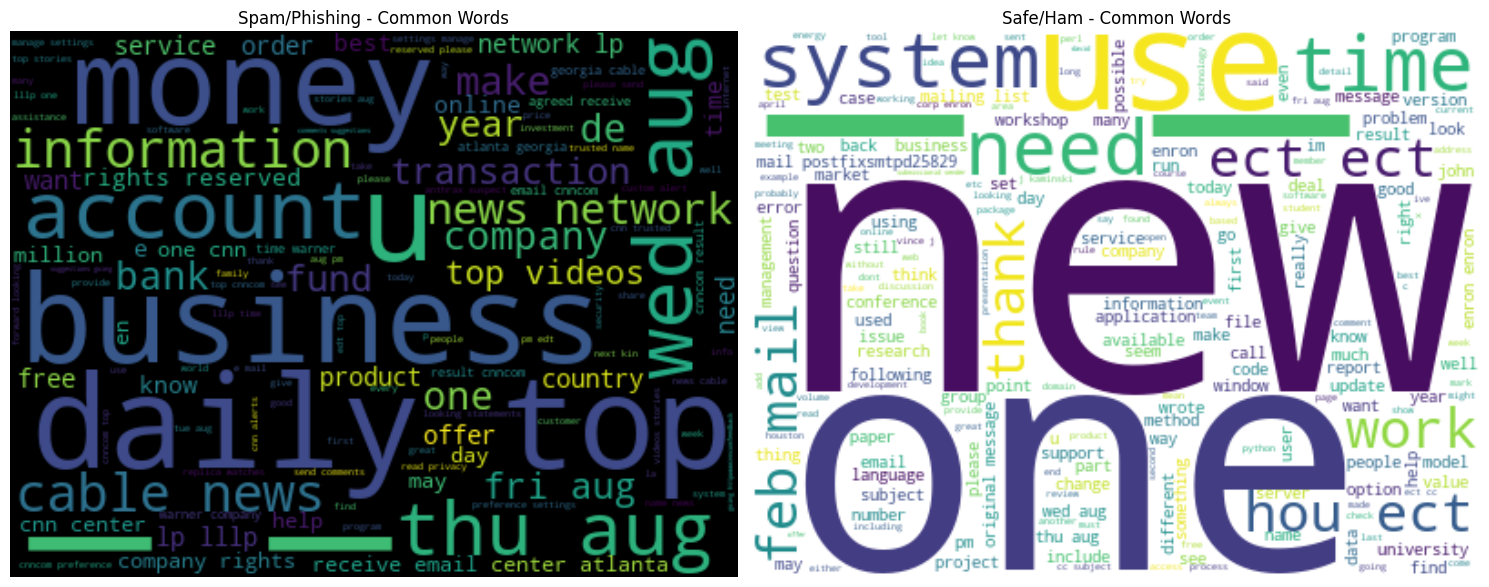

In [39]:
from wordcloud import WordCloud

# Separate spam and ham
spam_text = ' '.join(df[df[label_col] == 1][text_col].astype(str).sample(1000))
ham_text = ' '.join(df[df[label_col] == 0][text_col].astype(str).sample(1000))

# Create word clouds
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
wordcloud_spam = WordCloud(width=400, height=300, background_color='black').generate(spam_text)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Spam/Phishing - Common Words')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_ham = WordCloud(width=400, height=300, background_color='white').generate(ham_text)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Safe/Ham - Common Words')
plt.axis('off')

plt.tight_layout()
plt.show()

In [40]:
# Check for money-related words
money_words = ['money', 'win', 'prize', 'million', 'dollar', 'cash', 
               'free', 'offer', 'buy', 'sale', 'discount', 'price']

def count_money_words(text):
    text = str(text).lower()
    return sum(1 for word in money_words if word in text)

df['money_word_count'] = df[text_col].apply(count_money_words)
print(df.groupby(label_col)['money_word_count'].describe())

         count      mean       std  min  25%  50%  75%   max
label                                                       
0      39595.0  0.785352  1.207463  0.0  0.0  0.0  1.0  12.0
1      42891.0  1.179618  1.540184  0.0  0.0  1.0  2.0  11.0


In [41]:
# Check for product names (common in spam)
product_words = ['cialis', 'viagra', 'xanax', 'valium', 'weight', 'loss', 
                 'wireless', 'software', 'pills', 'drugs']

def count_product_words(text):
    text = str(text).lower()
    return sum(1 for word in product_words if word in text)

df['product_word_count'] = df[text_col].apply(count_product_words)
print(df.groupby(label_col)['product_word_count'].describe())

         count      mean       std  min  25%  50%  75%  max
label                                                      
0      39595.0  0.126228  0.397214  0.0  0.0  0.0  0.0  6.0
1      42891.0  0.212119  0.603057  0.0  0.0  0.0  0.0  8.0


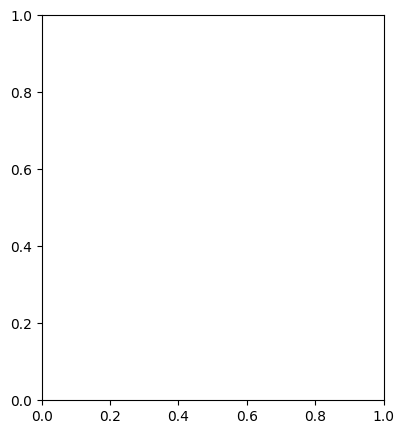

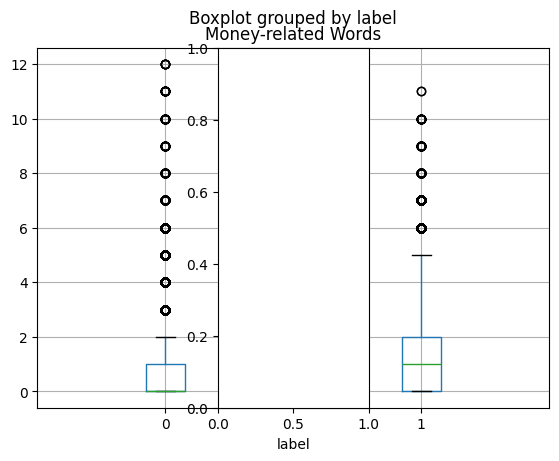

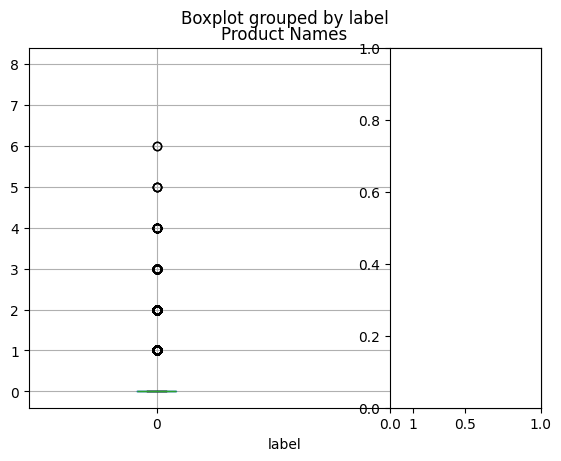

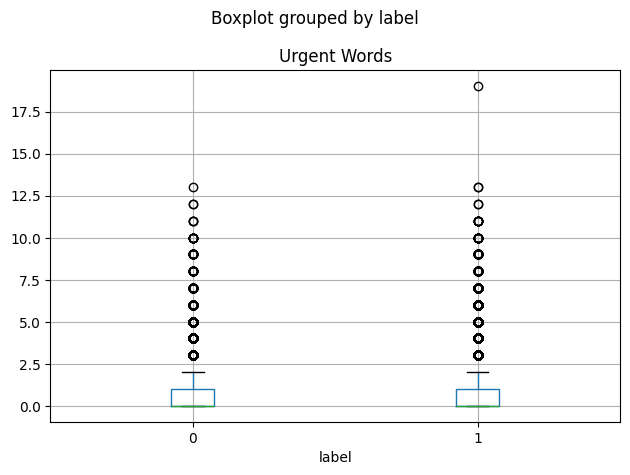

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df.boxplot(column='money_word_count', by=label_col)
plt.title('Money-related Words')

plt.subplot(1, 3, 2)
df.boxplot(column='product_word_count', by=label_col)
plt.title('Product Names')

plt.subplot(1, 3, 3)
df.boxplot(column='urgent_word_count', by=label_col)
plt.title('Urgent Words')

plt.tight_layout()
plt.show()

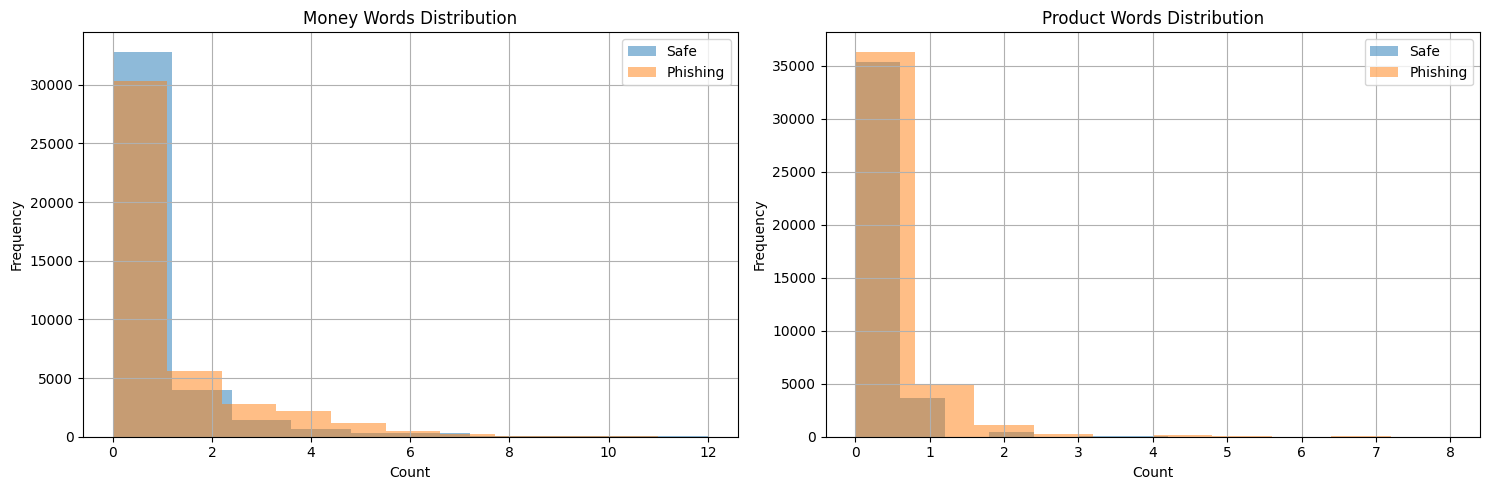

In [43]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
df.groupby(label_col)['money_word_count'].hist(alpha=0.5, bins=10)
plt.title('Money Words Distribution')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.legend(['Safe', 'Phishing'])

plt.subplot(1, 2, 2)
df.groupby(label_col)['product_word_count'].hist(alpha=0.5, bins=10)
plt.title('Product Words Distribution')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.legend(['Safe', 'Phishing'])

plt.tight_layout()
plt.show()

In [44]:
# Combine all the spam indicators
df['spam_score'] = (
    df['money_word_count'] * 2 + 
    df['product_word_count'] * 3 + 
    df['urgent_word_count'] * 1
)

# Compare
print(df.groupby(label_col)['spam_score'].describe())

         count      mean       std  min  25%  50%  75%   max
label                                                       
0      39595.0  2.548832  3.740437  0.0  0.0  2.0  3.0  54.0
1      42891.0  3.844653  4.429737  0.0  0.0  2.0  5.0  48.0


<Figure size 1000x600 with 0 Axes>

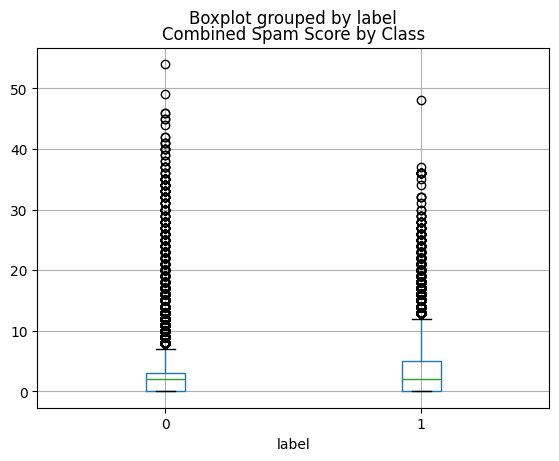

In [45]:
# Visualize the combined score
plt.figure(figsize=(10, 6))
df.boxplot(column='spam_score', by=label_col)
plt.title('Combined Spam Score by Class')
plt.show()

In [46]:
# List all features we've created
feature_cols = ['email_length', 'word_count', 'sentence_count', 
                'urgent_word_count', 'money_word_count', 'product_word_count',
                'exclamation_count']

print("Features created:")
for col in feature_cols:
    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col} (not created yet)")

Features created:
✅ email_length
✅ word_count
✅ sentence_count
✅ urgent_word_count
✅ money_word_count
✅ product_word_count
❌ exclamation_count (not created yet)


In [47]:
# Make sure we have all features
feature_cols = ['email_length', 'word_count', 'sentence_count', 
                'urgent_word_count', 'money_word_count', 'product_word_count',
                'exclamation_count']

# Check which features exist
available_features = [col for col in feature_cols if col in df.columns]
print(f"Using {len(available_features)} features: {available_features}")

# Create feature matrix X and target vector y
X = df[available_features]
y = df[label_col]

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"✅ Target vector shape: {y.shape}")

Using 6 features: ['email_length', 'word_count', 'sentence_count', 'urgent_word_count', 'money_word_count', 'product_word_count']

✅ Feature matrix shape: (82486, 6)
✅ Target vector shape: (82486,)


In [48]:
# Check if any features have missing values
print(X.isnull().sum())

email_length          0
word_count            0
sentence_count        0
urgent_word_count     0
money_word_count      0
product_word_count    0
dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} emails")
print(f"Test set size: {X_test.shape[0]} emails")
print(f"\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

Training set size: 65988 emails
Test set size: 16498 emails

Training class distribution:
label
1    0.519973
0    0.480027
Name: proportion, dtype: float64


In [50]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data only (never fit on test data!)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled")
print(f"Mean of training features (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Std of training features (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

✅ Features scaled
Mean of training features (should be ~0): [ 0. -0.  0.  0.  0.  0.]
Std of training features (should be ~1): [1. 1. 0. 1. 1. 1.]


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

✅ Model Accuracy: 0.7967 (79.67%)


In [52]:
# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Phishing (1)']))


📊 Classification Report:
              precision    recall  f1-score   support

    Safe (0)       0.79      0.79      0.79      7919
Phishing (1)       0.81      0.80      0.80      8579

    accuracy                           0.80     16498
   macro avg       0.80      0.80      0.80     16498
weighted avg       0.80      0.80      0.80     16498



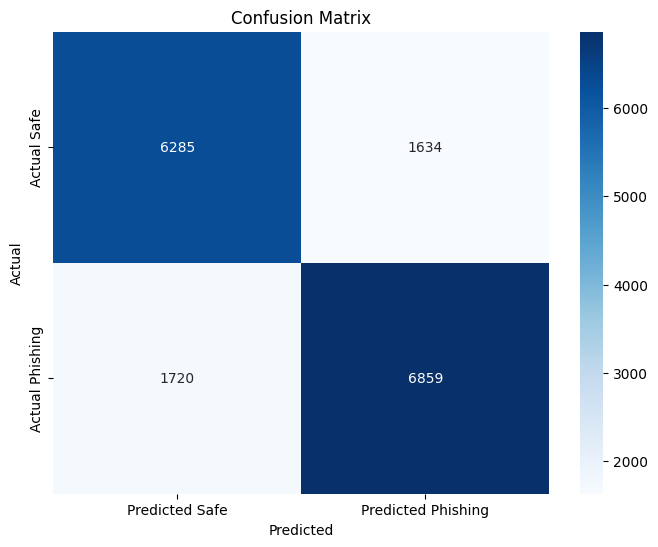

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Safe', 'Predicted Phishing'],
            yticklabels=['Actual Safe', 'Actual Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

📌 Feature Importance:
              feature  importance
0        email_length    0.495684
1          word_count    0.318134
4    money_word_count    0.082387
3   urgent_word_count    0.071694
5  product_word_count    0.032102
2      sentence_count    0.000000


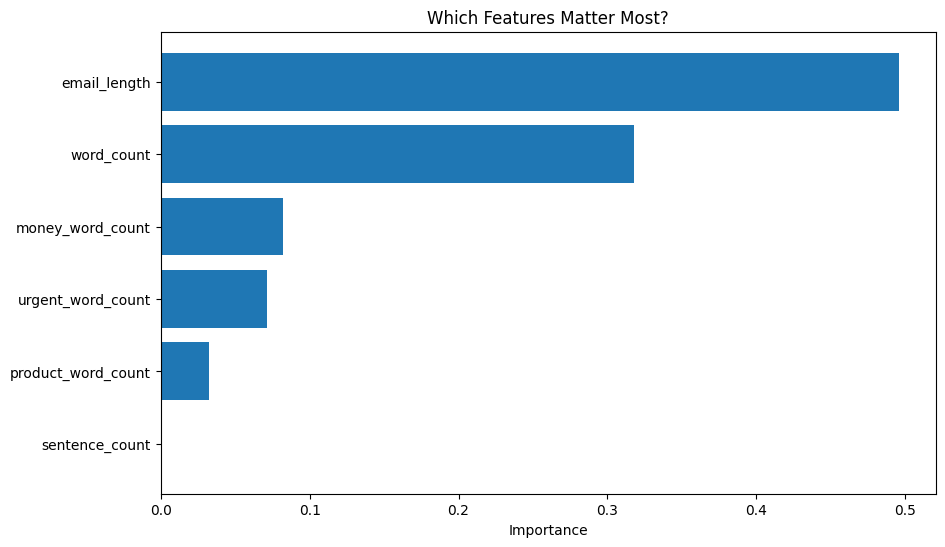

In [54]:
# Get feature importance
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': importance
}).sort_values('importance', ascending=False)

print("📌 Feature Importance:")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Which Features Matter Most?')
plt.gca().invert_yaxis()
plt.show()

In [55]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model and scaler
joblib.dump(model, '../models/phishing_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Model saved to ../models/phishing_model.pkl")
print("✅ Scaler saved to ../models/scaler.pkl")

✅ Model saved to ../models/phishing_model.pkl
✅ Scaler saved to ../models/scaler.pkl


In [59]:
# Save your final notebook
# File → Save (or Ctrl+S)

# Save your model and scaler again to be sure
import joblib
joblib.dump(model, '../models/final_model_part1.pkl')
joblib.dump(scaler, '../models/final_scaler_part1.pkl')
print("✅ Final model saved")

✅ Final model saved


# Phishing Detection Project - Part 1 Complete (March 19th)

## Dataset
- 82,486 emails (42,891 phishing, 39,595 safe)
- Features used: email_length, word_count, sentence_count, 
  urgent_word_count, money_word_count, product_word_count

## Model Performance
- Random Forest Classifier
- 80% accuracy on test set
- Balanced precision/recall (~80% for both classes)

## Key Insights
- Email length and word count are strongest predictors
- Money-related words are important (8% feature importance)
- Urgent language matters (7% feature importance)

## Next Steps for Part 2
- Add TF-IDF text features
- Try XGBoost model
- Aim for 85%+ accuracy
- Build prediction API for backend team